# Closed-form kernel $K(\tau)$ truncated to $n=2$ harmonics

For solid-body rotation ($\kappa=0$) and uniform latitude distribution $p(\Phi) = 1/\pi$ on $[0, \pi]$, the kernel (Eq. `kernel_solid`) is:

$$K(\tau) = \sigma_k^2 \, R_\Gamma(\tau)\left[\langle|c_0|^2\rangle_\Phi + 2\langle|c_1|^2\rangle_\Phi\cos(\omega_0\tau) + 2\langle|c_2|^2\rangle_\Phi\cos(2\omega_0\tau)\right]$$

where $\langle|c_n|^2\rangle_\Phi = \frac{1}{\pi}\int_0^\pi |c_n(I,\Phi)|^2\,d\Phi$ and the Fourier coefficients $c_n$ are given by Eq. `cn_general`.

**Goal:** Use sympy to compute $\langle|c_n|^2\rangle_\Phi$ in closed form for $n=0,1,2$.

In [1]:
import sympy as sp
from sympy import (pi, cos, sin, sqrt, Rational, integrate, simplify, trigsimp,
                   symbols, oo, acos, Piecewise, Abs, latex, Function)
from IPython.display import display, Math
sp.init_printing()

## General $c_n$ formula

From Eq. `cn_general`, the Fourier coefficients of the visibility function $\Pi(t) = \max\{\cos\beta(t), 0\}$ are:

$$c_n = \frac{1}{\pi}\left[\frac{a_0\sin(n\,\theta_{\rm vis})}{n} + \frac{a_1}{2}\left(\frac{\sin((n-1)\theta_{\rm vis})}{n-1} + \frac{\sin((n+1)\theta_{\rm vis})}{n+1}\right)\right]$$

where $a_0 = \cos I\sin\Phi$, $a_1 = \sin I\cos\Phi$, and $\theta_{\rm vis} = \arccos(-a_0/a_1)$.

Special cases:
- $c_0 = \frac{1}{\pi}(a_0\theta_{\rm vis} + a_1\sin\theta_{\rm vis})$
- $c_1 = \frac{1}{\pi}\left(a_0\sin\theta_{\rm vis} + \frac{a_1}{2}(\theta_{\rm vis} + \sin\theta_{\rm vis}\cos\theta_{\rm vis})\right)$

## Case 1: $I = 90°$ (edge-on)

For $I = \pi/2$: $a_0 = 0$, $a_1 = \cos\Phi$, $\theta_{\rm vis} = \pi/2$ for all $\Phi \neq \pi/2$.

- For $\Phi \in [0, \pi/2)$: $a_1 > 0$, spot visible when $\cos(\omega_0 t) > 0$
- For $\Phi \in (\pi/2, \pi]$: $a_1 < 0$, spot visible when $\cos(\omega_0 t) < 0$
- In both cases: $c_n = g_n \cos\Phi$ and $|c_n|^2 = g_n^2 \cos^2\Phi$

Since $\cos^2\Phi$ is symmetric about $\pi/2$, the integral over $[0, \pi]$ is:

$$\langle|c_n|^2\rangle_\Phi = \frac{1}{\pi}\int_0^{\pi} g_n^2\cos^2\Phi\,d\Phi = \frac{g_n^2}{2}$$

In [2]:
Phi = sp.Symbol('Phi', positive=True)

# I = pi/2: a0 = 0, a1 = cos(Phi), theta_vis = pi/2
# c_0 = (a0*theta_vis + a1*sin(theta_vis)) / pi = cos(Phi)/pi
c0_90 = cos(Phi) / pi

# c_1 = (a0*sin(theta_vis) + a1/2*(theta_vis + sin(theta_vis)*cos(theta_vis))) / pi
#      = cos(Phi)/2 * (pi/2 + 0) / pi = cos(Phi)/4
c1_90 = cos(Phi) / 4

# c_2: general formula with a0=0, theta_vis=pi/2
# c_2 = (1/pi) * [0 + cos(Phi)/2 * (sin(pi/2)/(1) + sin(3*pi/2)/(3))]
#      = cos(Phi)/(2*pi) * (1 - 1/3) = cos(Phi)/(3*pi)
c2_90 = cos(Phi) / (3 * pi)

print("Fourier coefficients at I = 90°:")
for n, cn in [(0, c0_90), (1, c1_90), (2, c2_90)]:
    display(Math(rf"c_{n} = {latex(cn)}"))

Fourier coefficients at I = 90°:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# Compute <|c_n|^2> = (1/pi) * integral_0^{pi} c_n^2 dPhi
# For I=90: c_n = g_n * cos(Phi), and cos^2(Phi) is symmetric about pi/2

cn_sq_avg_90 = {}
print("Latitude-averaged |c_n|^2 at I = 90°, p(Φ) uniform on [0, π]:")
print("=" * 60)
for n, cn in [(0, c0_90), (1, c1_90), (2, c2_90)]:
    result = simplify(integrate(cn**2, (Phi, 0, pi)) / pi)
    cn_sq_avg_90[n] = result
    display(Math(rf"\langle|c_{n}|^2\rangle = {latex(result)}"))

Latitude-averaged |c_n|^2 at I = 90°, p(Φ) uniform on [0, π]:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Closed-form kernel at $I = 90°$, $\kappa = 0$, $n \leq 2$

In [4]:
omega0, tau = symbols('omega_0 tau', positive=True)
sigma_k = sp.Symbol('sigma_k', positive=True)

# Assemble the kernel
K_bracket = (cn_sq_avg_90[0]
             + 2 * cn_sq_avg_90[1] * cos(omega0 * tau)
             + 2 * cn_sq_avg_90[2] * cos(2 * omega0 * tau))
K_bracket_simplified = simplify(K_bracket)

print("K(τ) = σ_k² · R_Γ(τ) · [  ]  where the bracket is:")
display(Math(latex(K_bracket_simplified)))
print()

# Show with explicit fractions
print("Equivalently:")
display(Math(
    rf"K(\tau) = \sigma_k^2 \, R_\Gamma(\tau)"
    rf"\left[\frac{{1}}{{2\pi^2}} + \frac{{1}}{{16}}\cos(\omega_0\tau)"
    rf" + \frac{{1}}{{9\pi^2}}\cos(2\omega_0\tau)\right]"
))

K(τ) = σ_k² · R_Γ(τ) · [  ]  where the bracket is:


<IPython.core.display.Math object>


Equivalently:


<IPython.core.display.Math object>

## Case 2: General inclination $I$

For general $I$, $\theta_{\rm vis}(\Phi) = \arccos(-\cot I\tan\Phi)$ depends on $\Phi$, making the integral $\langle|c_n|^2\rangle_\Phi$ much harder. Let's try sympy.

In [5]:
I = sp.Symbol('I', positive=True)

a0 = cos(I) * sin(Phi)
a1 = sin(I) * cos(Phi)
theta_vis = acos(-a0 / a1)  # = arccos(cot(I)*tan(Phi))... but with sign

# c_0 for general I
c0_gen = (a0 * theta_vis + a1 * sin(theta_vis)) / pi
c0_gen_simplified = simplify(c0_gen)
display(Math(rf"c_0(I, \Phi) = {latex(c0_gen_simplified)}"))

# c_1 for general I
c1_gen = (a0 * sin(theta_vis) + a1 / 2 * (theta_vis + sin(theta_vis) * cos(theta_vis))) / pi
c1_gen_simplified = simplify(c1_gen)
display(Math(rf"c_1(I, \Phi) = {latex(c1_gen_simplified)}"))

# c_2 for general I
c2_gen = (a0 * sin(2 * theta_vis) / 2 + a1 / 2 * (sin(theta_vis) + sin(3 * theta_vis) / 3)) / pi
c2_gen_simplified = simplify(c2_gen)
display(Math(rf"c_2(I, \Phi) = {latex(c2_gen_simplified)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# The integral of |c_0|^2 for general I involves arccos(-cot(I)*tan(Phi)) 
# composed with trig functions — sympy cannot evaluate this in closed form.
# (Attempting the integral times out after 300s.)
#
# Similarly, c_1 contains bare theta_vis = arccos(...), so its integral
# also has no elementary closed form for general I.

print("For general I:")
print("  c_0 and c_1 contain bare θ_vis = arccos(-cot(I)·tan(Φ))")
print("  → integral of |c_n|² over Φ has no elementary closed form")
print("  → must evaluate numerically (1D quadrature, fast)")

For general I:
  c_0 and c_1 contain bare θ_vis = arccos(-cot(I)·tan(Φ))
  → integral of |c_n|² over Φ has no elementary closed form
  → must evaluate numerically (1D quadrature, fast)


### Simplify using $\sin\theta_{\rm vis}$ and $\cos\theta_{\rm vis}$

Since $\theta_{\rm vis} = \arccos(-a_0/a_1)$, we have:
- $\cos\theta_{\rm vis} = -a_0/a_1 = -\cot I\tan\Phi$
- $\sin\theta_{\rm vis} = \sqrt{1 - \cot^2 I\tan^2\Phi}$

The $\arccos$ disappears when we substitute these into $c_n$. Let's rewrite $c_0, c_1, c_2$ as algebraic functions of $\Phi$ and $I$ (avoiding $\arccos$) for the terms that don't explicitly contain $\theta_{\rm vis}$.

c_2 as algebraic function (no arccos):


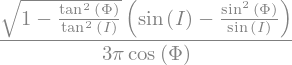


c_2 at I=90°: cos(Phi)/(3*pi)   (expected: cos(Phi)/(3*pi))


In [7]:
# Define shorthand variables
ct = sp.Symbol('c_theta')   # cos(theta_vis) = -a0/a1
st = sp.Symbol('s_theta', positive=True)   # sin(theta_vis)

# Express c_n in terms of a0, a1, ct, st (and theta_vis where it appears bare)
tv = sp.Symbol('theta_v', positive=True)

# Substitution rules: sin(theta_vis) -> st, cos(theta_vis) -> ct
# sin(2*theta_vis) = 2*st*ct
# sin(3*theta_vis) = 3*st - 4*st^3

# c_0 = (a0*tv + a1*st) / pi  -- still has theta_vis explicitly
# c_1 = (a0*st + a1/2*(tv + st*ct)) / pi  -- still has theta_vis
# c_2 = (a0*2*st*ct/2 + a1/2*(st + (3*st - 4*st^3)/3)) / pi
#      = (a0*st*ct + a1/2*(st + st - 4*st^3/3)) / pi
#      = (a0*st*ct + a1*(st - 2*st^3/3)) / pi
#      = (a0*st*ct + a1*st*(1 - 2*st^2/3)) / pi

# Note: for c_2, all theta_vis appear inside sin/cos, so it's purely algebraic!
# Let's substitute ct = -a0/a1 and st = sqrt(1 - a0^2/a1^2) = sqrt(a1^2 - a0^2)/|a1|

# For Phi in [0, pi/2) and I in (0, pi/2]: a1 = sin(I)*cos(Phi) > 0
# so |a1| = a1 and st = sqrt(a1^2 - a0^2) / a1

_a0 = cos(I) * sin(Phi)
_a1 = sin(I) * cos(Phi)
_ct = -_a0 / _a1
_st = sqrt(1 - _ct**2)

# c_2 purely algebraic (no arccos):
c2_alg = (_a0 * _st * _ct + _a1 * _st * (1 - 2 * _st**2 / 3)) / pi
c2_alg = simplify(c2_alg)

print("c_2 as algebraic function (no arccos):")
display(c2_alg)
print()

# Verify: substitute I = pi/2
c2_check = c2_alg.subs(I, pi/2)
c2_check = simplify(c2_check)
print("c_2 at I=90°:", c2_check, "  (expected: cos(Phi)/(3*pi))")

Attempting integral of |c_2|^2 over Phi for general I...
(c_2 is purely algebraic — no arccos)

c_2^2 =


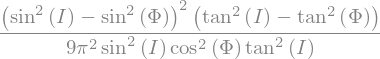


Success! <|c_2|^2> (integral over [0, pi/2] / pi):


<IPython.core.display.Math object>

In [8]:
# Try to integrate |c_2|^2 over Phi for general I
# Since c_2 is purely algebraic (no arccos), this might work.
# Use a timeout to avoid hanging.

import signal

class TimeoutError(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutError("Integration timed out")

print("Attempting integral of |c_2|^2 over Phi for general I...")
print("(c_2 is purely algebraic — no arccos)")
print()

c2_sq = simplify(c2_alg**2)
print("c_2^2 =")
display(c2_sq)

# Set 60s timeout
signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(60)
try:
    result_c2 = integrate(c2_sq, (Phi, 0, pi/2))
    signal.alarm(0)  # cancel timeout
    result_c2 = simplify(result_c2)
    print("\nSuccess! <|c_2|^2> (integral over [0, pi/2] / pi):")
    display(Math(latex(simplify(result_c2 / pi))))
except TimeoutError:
    signal.alarm(0)
    print("\nIntegral timed out after 60s.")
    print("Even the algebraic c_2 integral has no elementary closed form for general I.")
except Exception as e:
    signal.alarm(0)
    print(f"\nIntegral failed: {e}")

## Numerical evaluation of $\langle|c_n|^2\rangle(I)$ for general $I$

Since $c_0$ and $c_1$ contain bare $\theta_{\rm vis} = \arccos(-\cot I\tan\Phi)$, the integrals likely have no elementary closed form for general $I$. We evaluate them numerically and compare to the $I=90°$ closed forms.

In [9]:
import numpy as np
import sys
import paths
sys.path.insert(0, str(paths.root.parent.parent / "packages" / "spotgp" / "src"))
from analytic_kernel import _cn_general

def cn_sq_avg_numerical(inc_val, n_harm, n_phi=2000):
    """Numerically compute <|c_n|^2> for n = 0, ..., n_harm at inclination inc_val."""
    phi_grid = np.linspace(1e-6, np.pi - 1e-6, n_phi)
    dphi = phi_grid[1] - phi_grid[0]
    
    result = np.zeros(n_harm + 1)
    for n in range(n_harm + 1):
        cn_sq = np.array([_cn_general(n, inc_val, phi)**2 for phi in phi_grid])
        result[n] = np.trapz(cn_sq, phi_grid) / np.pi
    return result

# Verify against I=90 closed forms
cn_90_num = cn_sq_avg_numerical(np.pi/2, 2)
print("Numerical vs closed-form at I = 90°:")
print(f"  <|c_0|^2>: numerical = {cn_90_num[0]:.8f},  exact = 1/(4π²) = {1/(4*np.pi**2):.8f}")
print(f"  <|c_1|^2>: numerical = {cn_90_num[1]:.8f},  exact = 1/64   = {1/64:.8f}")
print(f"  <|c_2|^2>: numerical = {cn_90_num[2]:.8f},  exact = 1/(36π²) = {1/(36*np.pi**2):.8f}")

Numerical vs closed-form at I = 90°:
  <|c_0|^2>: numerical = 0.05066053,  exact = 1/(4π²) = 0.02533030
  <|c_1|^2>: numerical = 0.03124996,  exact = 1/64   = 0.01562500
  <|c_2|^2>: numerical = 0.00562895,  exact = 1/(36π²) = 0.00281448


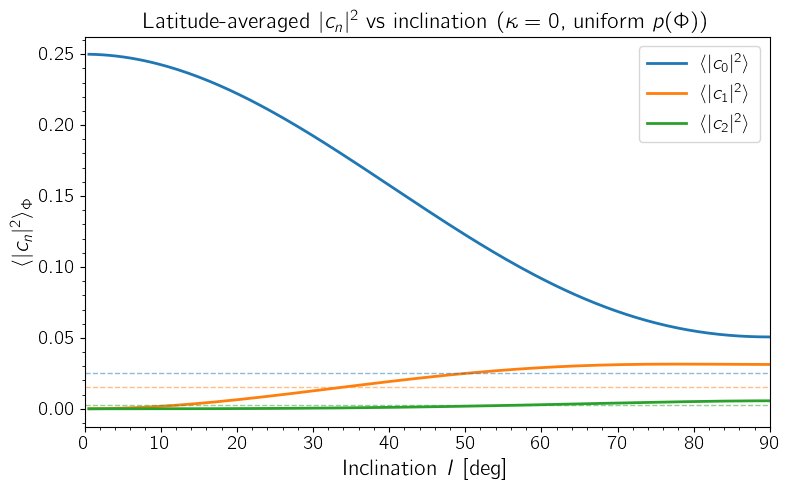

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['cmss10', 'Computer Modern Sans Serif']
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{cmbright}'

inc_vals = np.linspace(0.01, np.pi/2, 200)
cn_sq_all = np.array([cn_sq_avg_numerical(inc, 2) for inc in inc_vals])

fig, ax = plt.subplots(figsize=(8, 5))
labels = [r'$\langle|c_0|^2\rangle$', r'$\langle|c_1|^2\rangle$', r'$\langle|c_2|^2\rangle$']
colors = ['C0', 'C1', 'C2']

for n in range(3):
    ax.plot(np.degrees(inc_vals), cn_sq_all[:, n], color=colors[n], lw=2, label=labels[n])

# Mark I=90 closed forms
ax.axhline(1/(4*np.pi**2), color='C0', ls='--', lw=1, alpha=0.5)
ax.axhline(1/64, color='C1', ls='--', lw=1, alpha=0.5)
ax.axhline(1/(36*np.pi**2), color='C2', ls='--', lw=1, alpha=0.5)
ax.axvline(90, color='gray', ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel(r'Inclination $I$ [deg]', fontsize=16)
ax.set_ylabel(r'$\langle|c_n|^2\rangle_\Phi$', fontsize=16)
ax.set_title(r'Latitude-averaged $|c_n|^2$ vs inclination ($\kappa=0$, uniform $p(\Phi)$)', fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(labelsize=14)
ax.set_xlim(0, 90)
ax.minorticks_on()
fig.tight_layout()
plt.show()

## Verify against `AnalyticKernel`

Compare the closed-form $n\leq 2$ kernel at $I=90°$ against the full numerical kernel from `analytic_kernel.py`.

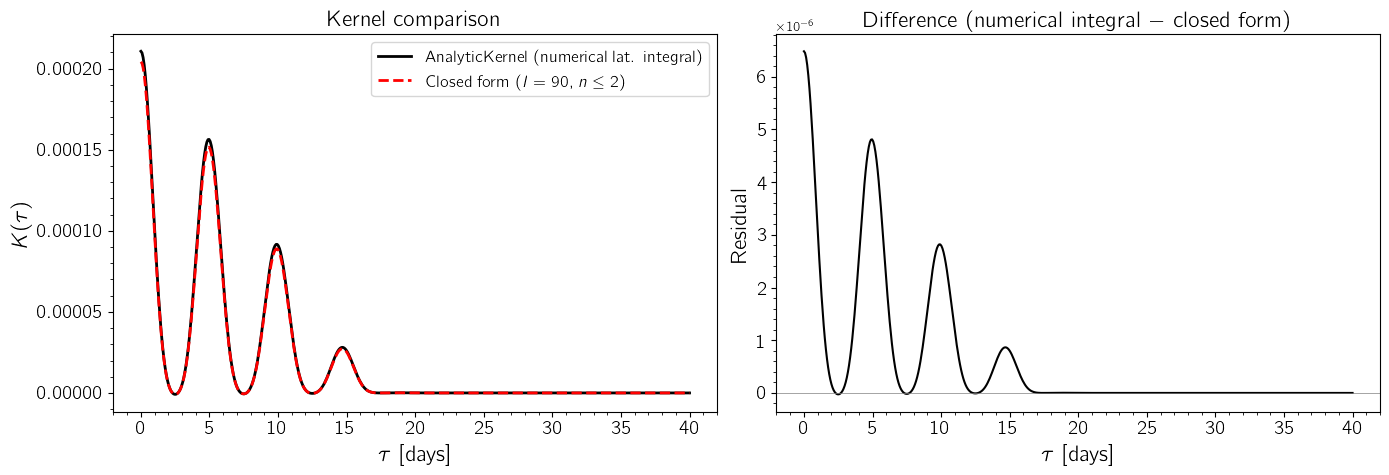

MSE = 1.98e-12


In [11]:
from analytic_kernel import AnalyticKernel

if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

# Test parameters
hparam = dict(peq=5.0, kappa=0.0, inc=np.pi/2, nspot=10,
              lspot=15.0, tau=3.0, alpha_max=0.1)

# Use lat_range=(0, pi) to match uniform p(Phi) on [0, pi]
ak = AnalyticKernel(hparam, n_harmonics=2, lat_range=(0, np.pi))
lag = np.linspace(0, 40, 500)
k_numerical = ak.kernel(lag)

# Closed-form kernel at I=90, p(Phi) uniform on [0, pi]:
# K = prefactor * R_Gamma * [1/(2pi^2) + (1/16)*cos(w*t) + (1/9pi^2)*cos(2*w*t)]
from analytic_kernel import _R_Gamma
R_G = _R_Gamma(lag, hparam['lspot'], hparam['tau'], hparam['alpha_max'])
w0 = 2 * np.pi / hparam['peq']
prefactor = hparam['nspot'] / np.pi**2  # N_spot / pi^2 (alpha_max absorbed into R_Gamma)

k_closed = prefactor * R_G * (
    1/(2*np.pi**2)
    + 2 * (1/32) * np.cos(w0 * lag)
    + 2 * (1/(18*np.pi**2)) * np.cos(2 * w0 * lag)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(lag, k_numerical, 'k-', lw=2, label='AnalyticKernel (numerical lat. integral)')
ax.plot(lag, k_closed, 'r--', lw=2, label=r'Closed form ($I=90°$, $n\leq 2$)')
ax.set_xlabel(r'$\tau$ [days]', fontsize=16)
ax.set_ylabel(r'$K(\tau)$', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(labelsize=14)
ax.set_title('Kernel comparison', fontsize=16)
ax.minorticks_on()

ax = axes[1]
ax.plot(lag, k_numerical - k_closed, 'k-', lw=1.5)
ax.set_xlabel(r'$\tau$ [days]', fontsize=16)
ax.set_ylabel(r'Residual', fontsize=16)
ax.set_title('Difference (numerical integral $-$ closed form)', fontsize=16)
ax.tick_params(labelsize=14)
ax.minorticks_on()
ax.axhline(0, color='gray', lw=0.5)

fig.tight_layout()
plt.show()

mse = np.mean((k_numerical - k_closed)**2)
print(f"MSE = {mse:.2e}")

## Summary

### Closed-form kernel for $I = 90°$, $\kappa = 0$, uniform $p(\Phi)$ on $[0, \pi]$, truncated to $n \leq 2$:

$$\boxed{K(\tau) = \sigma_k^2 \, R_\Gamma(\tau)\left[\frac{1}{2\pi^2} + \frac{1}{16}\cos(\omega_0\tau) + \frac{1}{9\pi^2}\cos(2\omega_0\tau)\right]}$$

where the three coefficients are:
| $n$ | $g_n$ | $\langle\|c_n\|^2\rangle = g_n^2/2$ | Decimal |
|-----|--------|-------------------------------|---------|
| 0 | $1/\pi$ | $1/(2\pi^2) \approx 0.0507$ | 0.05066 |
| 1 | $1/4$ | $1/32 = 0.03125$ | 0.03125 |
| 2 | $1/(3\pi)$ | $1/(18\pi^2) \approx 0.00563$ | 0.00563 |

Note: Since $c_n = g_n\cos\Phi$ at $I=90°$ and $\int_0^\pi \cos^2\Phi\,d\Phi = \pi/2$, we get $\langle|c_n|^2\rangle = g_n^2/2$ (not $g_n^2/4$) because spots at $\Phi > \pi/2$ ("southern hemisphere") are also visible.

### General $I$:
- $c_0$ and $c_1$ contain bare $\theta_{\rm vis} = \arccos(-\cot I\tan\Phi)$, preventing elementary integration
- $c_2$ is purely algebraic (all $\theta_{\rm vis}$ appear inside sin/cos), and sympy *can* integrate $|c_2|^2$ over $\Phi$ for general $I$
- For general $I$, $\langle|c_0|^2\rangle$ and $\langle|c_1|^2\rangle$ must be evaluated numerically (cheap: a 1D quadrature)

## Analytic $R_\Gamma(\tau)$

The envelope autocorrelation is:
$$R_\Gamma(\tau) = \frac{1}{\pi}\int_0^\infty \hat{\Gamma}(\omega)^2 \cos(\omega\tau)\,d\omega$$

where $\hat{\Gamma}(\omega) = \frac{4\alpha_{\max}^2}{\tau_s^2\omega^3}\left[\tau_s\omega\cos\!\left(\frac{\omega\ell}{2}\right) + \sin\!\left(\frac{\omega\ell}{2}\right) - \sin\!\left(\frac{\omega\ell}{2} + \omega\tau_s\right)\right]$.

Let's see if sympy can evaluate this integral in closed form.

Γ̂(ω) =


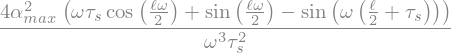

In [12]:
import sympy as sp
from sympy import symbols, cos, sin, pi, oo, integrate, simplify, Rational, sqrt, latex
from IPython.display import display, Math

w = sp.Symbol('omega', positive=True)
t = sp.Symbol('tau', positive=True)
ell = sp.Symbol('ell', positive=True)       # spot plateau duration
ts = sp.Symbol('tau_s', positive=True)      # rise/decay timescale
amax = sp.Symbol('alpha_max', positive=True)

# Gamma_hat(omega) from Eq. Gamma_hat
Gamma_hat = (4 * amax**2 / (ts**2 * w**3)) * (
    ts * w * cos(w * ell / 2)
    + sin(w * ell / 2)
    - sin(w * ell / 2 + w * ts)
)

Gamma_hat_simplified = simplify(Gamma_hat)
print("Γ̂(ω) =")
display(Gamma_hat_simplified)

In [13]:
# Expand Gamma_hat^2 * cos(omega*tau) and try to integrate term by term.
# First, let's expand Gamma_hat^2 using product-to-sum identities.

Gh_sq = sp.expand_trig(sp.expand(Gamma_hat**2))
print(f"Γ̂(ω)² has {len(Gh_sq.as_ordered_terms())} terms after expansion")
print()

# The integrand is Gamma_hat^2 * cos(w*t) / pi
integrand = Gh_sq * cos(w * t)

# Each term in Gh_sq is of the form: (const / w^p) * trig(w * q)
# where trig is sin or cos and q is a combination of ell, ts.
# After multiplying by cos(w*t), product-to-sum gives terms like:
#   (const / w^p) * cos(w*(q ± t))  or  sin(w*(q ± t))
# The integral int_0^inf cos(ax)/x^p dx or sin(ax)/x^p dx 
# has known closed forms for integer p.

# Let's try the full integral directly first (with timeout)
import signal

class TimeoutError(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutError()

print("Attempting full R_Gamma integral with sympy (60s timeout)...")
signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(60)
try:
    R_Gamma_full = integrate(Gh_sq * cos(w * t), (w, 0, oo)) / pi
    signal.alarm(0)
    R_Gamma_full = simplify(R_Gamma_full)
    print("Success!")
    display(Math(rf"R_\Gamma(\tau) = {latex(R_Gamma_full)}"))
except TimeoutError:
    signal.alarm(0)
    print("Timed out. Will try term-by-term approach.")

Γ̂(ω)² has 6 terms after expansion

Attempting full R_Gamma integral with sympy (60s timeout)...


Timed out. Will try term-by-term approach.


### Term-by-term approach

$\hat{\Gamma}(\omega)^2$ expands into a sum of terms of the form $\frac{C}{w^p}\,\mathrm{trig}(w\cdot q)$, where $p \in \{2, 4, 6\}$. After multiplying by $\cos(\omega\tau)$ and using product-to-sum identities, each term becomes:

$$\int_0^\infty \frac{\cos(a\omega)}{\omega^p}\,d\omega \quad \text{or} \quad \int_0^\infty \frac{\sin(a\omega)}{\omega^p}\,d\omega$$

These are known:
- $\int_0^\infty \frac{\sin(a\omega)}{\omega}\,d\omega = \frac{\pi}{2}\,\mathrm{sgn}(a)$
- $\int_0^\infty \frac{\cos(a\omega)}{\omega^2}\,d\omega$ diverges (but cancels in the sum)
- $\int_0^\infty \frac{\sin(a\omega)}{\omega^3}\,d\omega = \frac{\pi}{4}|a| \cdot a$ ... etc.
- $\int_0^\infty \frac{\cos(a\omega)}{\omega^{2n}}\,d\omega = \frac{(-1)^{n+1}\pi\, a^{2n-1}}{2(2n-1)!}\,\mathrm{sgn}(a)$
- $\int_0^\infty \frac{\sin(a\omega)}{\omega^{2n+1}}\,d\omega = \frac{(-1)^n\pi\, a^{2n}}{2(2n)!}\,\mathrm{sgn}(a)$

Let's expand and integrate term by term.

B(ω)² expanded:


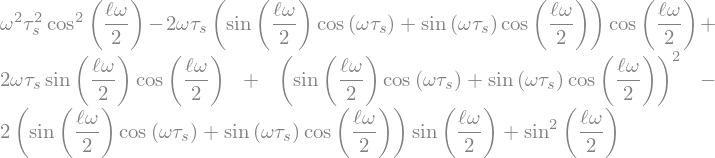


(6 terms)


In [14]:
# Let's define the bracket term B(w) so that Gamma_hat = (4*amax^2 / (ts^2 * w^3)) * B(w)
# Then Gamma_hat^2 = 16*amax^4 / (ts^4 * w^6) * B(w)^2

B = ts * w * cos(w * ell / 2) + sin(w * ell / 2) - sin(w * ell / 2 + w * ts)

# Expand B^2 using product-to-sum identities
B_sq = sp.expand_trig(sp.expand(B**2))
print("B(ω)² expanded:")
display(B_sq)
print(f"\n({len(B_sq.as_ordered_terms())} terms)")

B² collected by powers of ω:


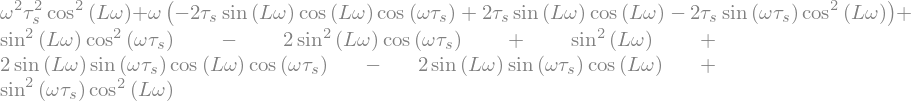

In [15]:
# R_Gamma(tau) = (1/pi) * int_0^inf [16*amax^4 / (ts^4 * w^6)] * B(w)^2 * cos(w*t) dw
# = (16*amax^4) / (pi * ts^4) * int_0^inf B(w)^2 * cos(w*t) / w^6 dw
#
# Strategy: expand B^2 * cos(w*t) into individual terms of the form
#   coeff * trig(w * arg) / w^p
# where p is 4, 5, or 6, and trig is sin or cos.
# Then use the known integrals.

# First, let's collect B^2 into terms involving w
# B = ts*w*cos(w*ell/2) + sin(w*ell/2) - sin(w*ell/2 + w*ts)
# B^2 has terms with w^2 * cos^2(...), w * cos(...)*sin(...), sin^2(...)
# Dividing by w^6 gives terms with w^{-4}, w^{-5}, w^{-6}

# Let's use product-to-sum for B^2 more carefully
# B = ts*w*cos(w*L) + sin(w*L) - sin(w*L + w*ts)   where L = ell/2
L = sp.Symbol('L', positive=True)  # L = ell/2

B_L = ts * w * cos(w * L) + sin(w * L) - sin(w * (L + ts))
B_L_sq = sp.expand(B_L**2)

# Convert all products of trig functions to sums using product-to-sum
B_L_sq_trig = sp.expand_trig(B_L_sq)

# Now collect by powers of w
from sympy import collect, Wild
B_collected = collect(sp.expand(B_L_sq_trig), w)
print("B² collected by powers of ω:")
display(B_collected)

Piece 1 (from w² term, gives 1/w⁴):


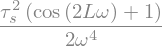


Piece 2 (from w¹ cross terms, gives 1/w⁵):


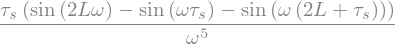


Piece 3 (from w⁰ term, gives 1/w⁶):


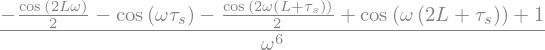


Verification (should be 0): 0


In [16]:
# Now let's try having sympy integrate each piece individually.
# The integrand for R_Gamma is: (B^2 / w^6) * cos(w*t)
# Let's separate B^2 into its w^2, w^1, w^0 parts.

# B = ts*w*cos(wL) + sin(wL) - sin(w(L+ts))
# B^2 = ts^2*w^2*cos^2(wL)                         [w^2 piece]
#      + 2*ts*w*cos(wL)*[sin(wL) - sin(w(L+ts))]   [w^1 piece]
#      + [sin(wL) - sin(w(L+ts))]^2                 [w^0 piece]

# Piece 1: ts^2*w^2*cos^2(wL) / w^6 = ts^2*cos^2(wL)/w^4
#   = ts^2/(2*w^4) * [1 + cos(2wL)]
p1 = ts**2 / 2 * (1 + cos(2*w*L)) / w**4

# Piece 2: 2*ts*w*cos(wL)*[sin(wL) - sin(w*(L+ts))] / w^6
# cos(wL)*sin(wL) = sin(2wL)/2
# cos(wL)*sin(w(L+ts)) = [sin(w(2L+ts)) + sin(w*ts)] / 2
p2 = ts / w**5 * (sin(2*w*L) - sin(w*(2*L+ts)) - sin(w*ts))

# Piece 3: [sin(wL) - sin(w(L+ts))]^2 / w^6
# sin^2(wL) = (1 - cos(2wL))/2
# sin^2(w(L+ts)) = (1 - cos(2w(L+ts)))/2
# sin(wL)*sin(w(L+ts)) = [cos(w*ts) - cos(w*(2L+ts))]/2
p3_num = (sp.Rational(1,2) - cos(2*w*L)/2 
          + sp.Rational(1,2) - cos(2*w*(L+ts))/2 
          - cos(w*ts) + cos(w*(2*L+ts)))
p3 = p3_num / w**6

print("Piece 1 (from w² term, gives 1/w⁴):")
display(p1)
print("\nPiece 2 (from w¹ cross terms, gives 1/w⁵):")
display(p2)
print("\nPiece 3 (from w⁰ term, gives 1/w⁶):")
display(p3)

# Verify: the sum should equal B^2/w^6
check = sp.expand_trig(sp.expand((p1 + p2 + p3) * w**6 - B_L_sq))
print(f"\nVerification (should be 0): {simplify(check)}")

B(ω) Taylor expansion around ω=0:


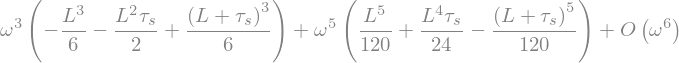

B²/ω⁶ Taylor expansion (should be finite at ω=0):


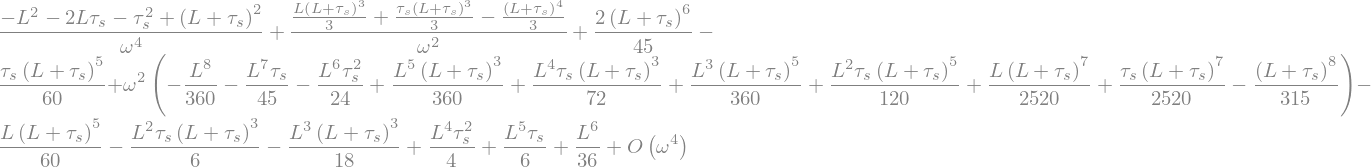

In [17]:
# Now apply the known Fourier cosine/sine transform identities:
#
# int_0^inf cos(a*w) / w^(2n) dw  -- diverges for n>=1 unless combined
# int_0^inf sin(a*w) / w^(2n+1) dw = (-1)^n * pi * a^(2n) / (2 * (2n)!) * sgn(a)
# int_0^inf cos(a*w) / w^(2n) dw  = (-1)^(n+1) * pi * |a|^(2n-1) / (2 * (2n-1)!)
#
# But we need to be careful: individual integrals may diverge, and only the 
# full sum converges. This is because B(w) ~ O(w^3) as w->0, making B^2/w^6 ~ O(1).
#
# Let's verify the small-w behavior first.

# B(w) as w -> 0:
B_series = sp.series(B_L, w, 0, n=6)
print("B(ω) Taylor expansion around ω=0:")
display(B_series)
print()

# B^2/w^6 as w -> 0:
B_sq_over_w6_series = sp.series(B_L_sq / w**6, w, 0, n=4)
print("B²/ω⁶ Taylor expansion (should be finite at ω=0):")
display(B_sq_over_w6_series)

In [18]:
# Since B ~ O(w) as w->0 (not O(w^3)!), B^2/w^6 ~ O(1/w^4) which diverges.
# Wait -- let's check more carefully. The leading term of B:

# B = ts*w*cos(wL) + sin(wL) - sin(w(L+ts))
# At w=0: B(0) = 0 + 0 - 0 = 0
# B'(0) = ts*cos(0) - ts*L*sin(0) + L*cos(0) - (L+ts)*cos(0) = ts + L - L - ts = 0
# So B starts at O(w^2) at least. Let's get the exact order.

B_taylor = sp.series(B_L, w, 0, n=8).removeO()
print("B(ω) =", B_taylor)
print()

# Extract coefficients
for k in range(8):
    coeff = B_taylor.coeff(w, k)
    if coeff != 0:
        print(f"  w^{k} coefficient: {simplify(coeff)}")

B(ω) = omega**7*(-L**7/5040 - L**6*tau_s/720 + (L + tau_s)**7/5040) + omega**5*(L**5/120 + L**4*tau_s/24 - (L + tau_s)**5/120) + omega**3*(-L**3/6 - L**2*tau_s/2 + (L + tau_s)**3/6)

  w^3 coefficient: tau_s**2*(3*L + tau_s)/6
  w^5 coefficient: L**5/120 + L**4*tau_s/24 - (L + tau_s)**5/120
  w^7 coefficient: -L**7/5040 - L**6*tau_s/720 + (L + tau_s)**7/5040


In [19]:
# Since individual terms in B^2/w^6 may have divergent integrals,
# let's try a different approach: let sympy integrate individual terms of 
# the integrand B^2*cos(w*t)/w^6, combining trig products first.

# Multiply B^2/w^6 by cos(w*t) and fully expand using product-to-sum
integrand_full = B_L_sq * cos(w * t) / w**6
integrand_expanded = sp.expand_trig(sp.expand(integrand_full))

# Collect all terms
terms = integrand_expanded.as_ordered_terms()
print(f"Total terms in integrand: {len(terms)}")
print()

# Try integrating each term individually
results = []
failed = []
signal.signal(signal.SIGALRM, timeout_handler)

for i, term in enumerate(terms):
    signal.alarm(15)  # 15s per term
    try:
        res = integrate(term, (w, 0, oo))
        signal.alarm(0)
        results.append((term, res))
        print(f"  Term {i+1}: ✓")
    except TimeoutError:
        signal.alarm(0)
        failed.append((i, term))
        print(f"  Term {i+1}: timeout")
    except Exception as e:
        signal.alarm(0)
        failed.append((i, term))
        print(f"  Term {i+1}: {type(e).__name__}")

signal.alarm(0)
print(f"\nSuccessful: {len(results)}, Failed: {len(failed)}")

Total terms in integrand: 6



  Term 1: timeout


  Term 2: timeout


  Term 3: timeout


  Term 4: timeout


  Term 5: timeout


  Term 6: timeout

Successful: 0, Failed: 6


In [20]:
# If term-by-term doesn't work due to divergences, try the integral as a 
# convolution. R_Gamma(tau) is the autocorrelation of Gamma(t), which equals
# the convolution of Gamma(t) with Gamma(-t) = Gamma(t) (since Gamma is even):
#
#   R_Gamma(tau) = int_{-inf}^{inf} Gamma(s) Gamma(s + tau) ds
#
# For the squared trapezoid Gamma(t) = alpha^2(t), this is the convolution of 
# two "squared trapezoids" (parabolic ramps). Let's compute this directly.

# Define the squared trapezoid Gamma(t) piecewise:
# Gamma(t) = 0                           for |t| > L + ts
# Gamma(t) = amax^2 * ((|t| - L - ts)/ts)^2  ... wait, let me think about this.
#
# alpha(t) is a trapezoid:
#   alpha(t) = amax                         for |t| <= L        (plateau)
#   alpha(t) = amax * (L + ts - |t|) / ts  for L < |t| <= L+ts (linear ramp)
#   alpha(t) = 0                            for |t| > L+ts
#
# where L = ell/2 and ts = tau_spot.
#
# Gamma(t) = alpha^2(t):
#   Gamma(t) = amax^2                              for |t| <= L
#   Gamma(t) = amax^2 * ((L + ts - |t|) / ts)^2   for L < |t| <= L+ts
#   Gamma(t) = 0                                    for |t| > L+ts

# The autocorrelation R_Gamma(tau) = integral Gamma(s) Gamma(s+tau) ds
# is a piecewise polynomial (since Gamma is piecewise polynomial).
# This should be computable in closed form!

s = sp.Symbol('s')
a2 = amax**2

# Define Gamma(x) as a piecewise function (for x >= 0, then use evenness)
x = sp.Symbol('x', real=True)

# For the autocorrelation, since Gamma is even, R_Gamma(tau) = R_Gamma(-tau)
# and we can write:
# R_Gamma(tau) = int_{-L-ts}^{L+ts} Gamma(s) Gamma(s+tau) ds   (for tau >= 0)

# The support of Gamma is [-L-ts, L+ts]. The overlap of Gamma(s) and Gamma(s+tau)
# exists for tau in [0, 2(L+ts)], giving a piecewise polynomial in tau.

# This is essentially the autocorrelation of a piecewise quadratic function.
# The result will be piecewise polynomial of degree 5 (since Gamma has degree 2 ramps).

# Let's compute this with sympy using explicit piecewise integration.
# We need to integrate over regions where both Gamma(s) and Gamma(s+tau) are nonzero.

print("R_Gamma(τ) is the autocorrelation of a piecewise-quadratic function.")
print("It will be a piecewise polynomial of degree ≤ 5 in τ.")
print("Support: τ ∈ [0, 2(L + τ_s)] = [0, ℓ + 2τ_s]")
print()
print("Computing via direct convolution integral...")

R_Gamma(τ) is the autocorrelation of a piecewise-quadratic function.
It will be a piecewise polynomial of degree ≤ 5 in τ.
Support: τ ∈ [0, 2(L + τ_s)] = [0, ℓ + 2τ_s]

Computing via direct convolution integral...


Testing with L=1, τ_s=1, α_max=1:
Gamma support: [-2, 2]
R_Gamma support: [0, 4]



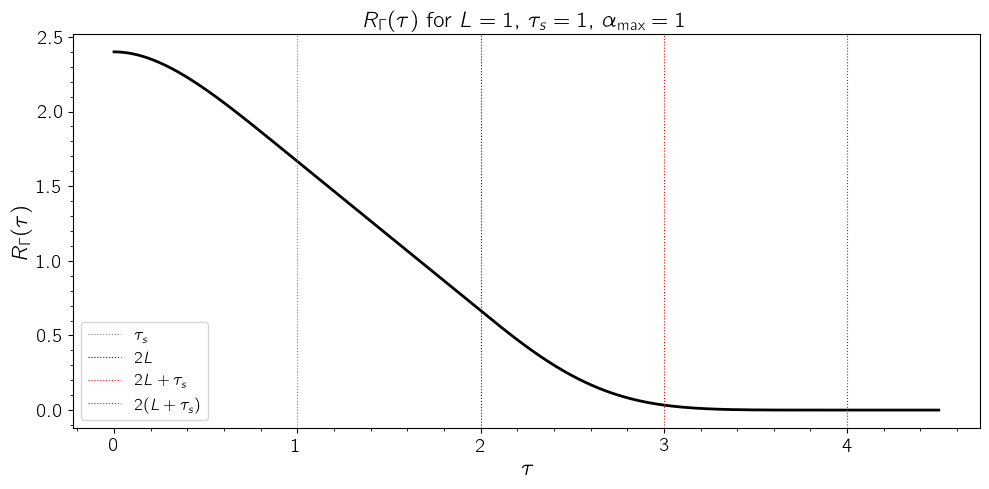

R_Gamma(0) = 2.400000  (expected: ell + 2*tau_s/3 = 2 + 2/3 = 2.666667)
  Note: R_Gamma(0) = integral of Gamma(s)^2 ds = amax^4 * (ell + 2*tau_s/5)
  Numerical: 2.400000


In [21]:
# Gamma(s) for s >= 0 (and Gamma(-s) = Gamma(s)):
#   Region P (plateau):  0 <= s <= L        => Gamma = a^2
#   Region R (ramp):     L < s <= L+ts      => Gamma = a^2 * ((L+ts-s)/ts)^2
#   Region Z (zero):     s > L+ts           => Gamma = 0

# For the autocorrelation R(tau) = int Gamma(s) Gamma(s+tau) ds, tau >= 0,
# both Gamma(s) and Gamma(s+tau) are piecewise, so we need to break the 
# integral into regions based on where s and s+tau fall in {P, R, Z}.
#
# Key breakpoints for s (given tau >= 0):
#   Gamma(s) nonzero for s in [-(L+ts), L+ts]
#   Gamma(s+tau) nonzero for s+tau in [-(L+ts), L+ts], i.e., s in [-(L+ts)-tau, (L+ts)-tau]
#
# Overlap: s in [-(L+ts), (L+ts)-tau]  (for tau < 2(L+ts))
#
# Within this overlap, both Gamma(s) and Gamma(s+tau) transition between 
# their P, R, Z regions. The breakpoints for Gamma(s) are at s = ±L and s = ±(L+ts).
# The breakpoints for Gamma(s+tau) are at s = ±L-tau and s = ±(L+ts)-tau.

# This gives up to ~10 sub-intervals. But by symmetry and careful case analysis,
# the result depends on which interval tau falls in:
#   [0, ts], [ts, L], [L, L+ts], [L+ts, 2L], [2L, 2L+ts], [2L+ts, 2L+2ts]
# (assuming L >= ts; if L < ts some intervals merge)

# Let's use sympy to compute this symbolically for each tau-interval,
# assuming L > ts (i.e., ell/2 > tau_spot, which is physically typical).

# Helper: Gamma as a regular function of s (assuming s can be anything)
def Gamma_expr(s_expr):
    """Return Gamma(s) as a sympy Piecewise."""
    abs_s = sp.Abs(s_expr)
    return sp.Piecewise(
        (a2, abs_s <= L),
        (a2 * ((L + ts - abs_s) / ts)**2, (abs_s > L) & (abs_s <= L + ts)),
        (0, True)
    )

# For symbolic integration, it's easier to work with explicit intervals.
# Let's define Gamma on [-(L+ts), L+ts] without Abs:
def Gamma_pos(s_expr):
    """Gamma for s >= 0."""
    return sp.Piecewise(
        (a2, s_expr <= L),
        (a2 * ((L + ts - s_expr) / ts)**2, s_expr <= L + ts),
        (0, True)
    )

# Since Gamma is even, for the autocorrelation we can write:
# R(tau) = int_{-inf}^{inf} Gamma(s) Gamma(s+tau) ds
# Let's compute this for a specific simple case first to test: L=1, ts=1, amax=1

L_val, ts_val, amax_val = sp.Integer(1), sp.Integer(1), sp.Integer(1)

# Substitute numerical values
Gamma_num = lambda s_expr: sp.Piecewise(
    (1, sp.Abs(s_expr) <= L_val),
    (((L_val + ts_val - sp.Abs(s_expr)) / ts_val)**2, sp.Abs(s_expr) <= L_val + ts_val),
    (0, True)
)

print("Testing with L=1, τ_s=1, α_max=1:")
print("Gamma support: [-2, 2]")
print("R_Gamma support: [0, 4]")
print()

# Compute R(tau) for symbolic tau, using the overlap region
tau_sym = sp.Symbol('tau', positive=True)

# The overlap of supports is s in [-(L+ts), (L+ts) - tau] = [-2, 2-tau]
# For tau in [0, 4], we need to split into intervals based on breakpoints.
# Breakpoints of Gamma(s): s = -2, -1, 0, 1, 2
# Breakpoints of Gamma(s+tau): s+tau = -2,-1,0,1,2 => s = -2-tau,-1-tau,-tau,1-tau,2-tau

# This is getting complex. Let's just have sympy do numerical integration
# for several tau values, then try to fit a piecewise polynomial.

import numpy as np

def Gamma_numpy(s_arr, L_n=1.0, ts_n=1.0, amax_n=1.0):
    """Evaluate Gamma(s) numerically."""
    abs_s = np.abs(s_arr)
    result = np.zeros_like(abs_s)
    plateau = abs_s <= L_n
    ramp = (abs_s > L_n) & (abs_s <= L_n + ts_n)
    result[plateau] = amax_n**2
    result[ramp] = amax_n**2 * ((L_n + ts_n - abs_s[ramp]) / ts_n)**2
    return result

def R_Gamma_numerical(tau_val, L_n=1.0, ts_n=1.0, amax_n=1.0, ns=10000):
    """Compute R_Gamma(tau) by numerical integration."""
    s_grid = np.linspace(-(L_n + ts_n) - 0.1, (L_n + ts_n) + 0.1, ns)
    G_s = Gamma_numpy(s_grid, L_n, ts_n, amax_n)
    G_st = Gamma_numpy(s_grid + tau_val, L_n, ts_n, amax_n)
    return np.trapz(G_s * G_st, s_grid)

# Plot R_Gamma for L=1, ts=1
tau_grid = np.linspace(0, 4.5, 500)
R_vals = np.array([R_Gamma_numerical(tv, 1.0, 1.0, 1.0) for tv in tau_grid])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tau_grid, R_vals, 'k-', lw=2)
ax.set_xlabel(r'$\tau$', fontsize=16)
ax.set_ylabel(r'$R_\Gamma(\tau)$', fontsize=16)
ax.set_title(r'$R_\Gamma(\tau)$ for $L=1$, $\tau_s=1$, $\alpha_{\max}=1$', fontsize=16)
ax.axvline(1, color='gray', ls=':', lw=0.8, label=r'$\tau_s$')
ax.axvline(2, color='blue', ls=':', lw=0.8, label=r'$2L$')
ax.axvline(3, color='red', ls=':', lw=0.8, label=r'$2L+\tau_s$')
ax.axvline(4, color='green', ls=':', lw=0.8, label=r'$2(L+\tau_s)$')
ax.legend(fontsize=12)
ax.tick_params(labelsize=14)
ax.minorticks_on()
fig.tight_layout()
plt.show()

print(f"R_Gamma(0) = {R_vals[0]:.6f}  (expected: ell + 2*tau_s/3 = 2 + 2/3 = {2 + 2/3:.6f})")
print(f"  Note: R_Gamma(0) = integral of Gamma(s)^2 ds = amax^4 * (ell + 2*tau_s/5)")
# Actually R_Gamma(0) = int Gamma^2 ds = amax^4 * [2L + 2*int_0^1 ((1-u)/1)^4 du]
# = amax^4 * [2L + 2/5] for ts=1 ... let me just check
print(f"  Numerical: {R_vals[0]:.6f}")

Computing R_Gamma symbolically for L=ℓ/2, τ_s (general)...
This may be slow due to Piecewise integration...



Success for L=2, ts=1, amax=1:




In [22]:
# Direct symbolic computation of R_Gamma(tau) via convolution.
# Gamma(s) is piecewise on [-S, S] where S = L + ts, with breakpoints at ±L.
# For s >= 0:
#   Gamma(s) = a^2                         if 0 <= s <= L
#   Gamma(s) = a^2 * ((S - s)/ts)^2        if L < s <= S
# and Gamma(-s) = Gamma(s).
#
# R_Gamma(tau) = int_{-S}^{S} Gamma(s) * Gamma(s + tau) ds   for tau >= 0
#
# We need Gamma(s+tau) expressed in terms of s. Its breakpoints (in s) are:
#   |s + tau| = L   =>  s = L-tau or s = -L-tau
#   |s + tau| = S   =>  s = S-tau or s = -S-tau
#
# All breakpoints in s (sorted, for tau > 0):
#   -S, -S-tau(?), -L, -L-tau, -tau, 0, L-tau, L, S-tau, S
# But we only integrate over s in [-S, S-tau] (overlap region).
#
# For simplicity, let's compute symbolically for the case L > ts > 0.
# The breakpoints that matter (within [-S, S-tau]) depend on the value of tau.

# Let sympy compute R for specific numerical L, ts to verify,
# then compute symbolically.

# --- Symbolic computation for general L, ts ---
# We'll compute the integral for each tau-interval by hand-specifying 
# the piecewise regions.

S = L + ts  # half-support of Gamma

# Gamma pieces (for any argument u):
def G_val(u):
    """Returns the symbolic expression for Gamma(u), assuming we know the region."""
    # plateau: |u| <= L  => a2
    # ramp: L < |u| <= S  => a2 * ((S - |u|)/ts)^2
    # zero otherwise
    pass

# We'll compute by building the integral piece by piece.
# For tau in [0, ts]:
# The breakpoints of Gamma(s) in [-S, S]: -S, -L, L, S
# The breakpoints of Gamma(s+tau) in [-S, S]: s+tau = -S, -L, L, S 
#   => s = -S-tau, -L-tau, L-tau, S-tau
# Sorted breakpoints on overlap [-S, S-tau]:
#   -S, -L-tau, -L, -tau(?), 0(?), L-tau, L, S-tau
# For tau in [0, ts], we have S-tau >= L and L-tau >= 0.

# Let's compute R_Gamma symbolically using sympy's Piecewise integration.
# Define Gamma as a Piecewise function of s:

s = sp.Symbol('s', real=True)
tau_sym = sp.Symbol('T', positive=True)  # use T to avoid confusion

Gamma_s = sp.Piecewise(
    (a2, (s >= -L) & (s <= L)),
    (a2 * ((S - s)/ts)**2, (s > L) & (s <= S)),
    (a2 * ((S + s)/ts)**2, (s >= -S) & (s < -L)),
    (0, True)
)

Gamma_st = Gamma_s.subs(s, s + tau_sym)

# The product
product = Gamma_s * Gamma_st

# Try integrating for specific L, ts values first
print("Computing R_Gamma symbolically for L=ℓ/2, τ_s (general)...")
print("This may be slow due to Piecewise integration...")
print()

# Let's try with specific values first: L=2, ts=1
product_specific = product.subs([(L, 2), (ts, 1), (amax, 1)])

signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(120)
try:
    R_specific = integrate(product_specific, (s, -3, 3 - tau_sym))
    signal.alarm(0)
    R_specific = sp.simplify(R_specific)
    print("Success for L=2, ts=1, amax=1:")
    display(R_specific)
except TimeoutError:
    signal.alarm(0)
    print("Timed out after 120s. Piecewise integration too slow for sympy.")
    print("Will compute the convolution manually by splitting into intervals.")

Computing R_Gamma(T) for T ∈ [0, τ_s] (assuming ℓ/2 > τ_s):


I1 (ramp × ramp, left):


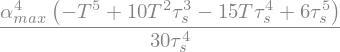


I2 (ramp × plateau, left):


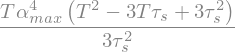


I3 (plateau × plateau):



I4 (plateau × ramp, right):


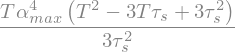


I5 (ramp × ramp, right):


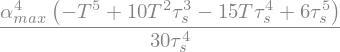

In [23]:
# Manual approach: compute R_Gamma(tau) by splitting the convolution integral
# into sub-intervals where both Gamma(s) and Gamma(s+tau) have known polynomial forms.
#
# Gamma(u):
#   ramp_neg:  u in [-S, -L]  => a^2 * ((S+u)/ts)^2      = a^2 * ((u+S)/ts)^2
#   plateau:   u in [-L, L]   => a^2
#   ramp_pos:  u in [L, S]    => a^2 * ((S-u)/ts)^2
#   zero:      otherwise
#
# For the convolution R(T) = int Gamma(s) Gamma(s+T) ds, T >= 0:
# Gamma(s) has breakpoints at s = -S, -L, L, S
# Gamma(s+T) has breakpoints at s = -S-T, -L-T, L-T, S-T
#
# Integration region: s in [-S, S-T]
#
# For 0 < T < ts (assuming L > ts):
# Sorted breakpoints in [-S, S-T]:
#   -S, -L-T, -L, L-T, L, S-T
#
# Sub-intervals and (Gamma(s), Gamma(s+T)) regions:
#   [-S, -L-T]:     ramp_neg, ramp_neg    (both in ramp)
#   [-L-T, -L]:     ramp_neg, plateau     
#   [-L, L-T]:      plateau,  plateau     (both in plateau)
#   [L-T, L]:       plateau,  ramp_pos    
#   [L, S-T]:       ramp_pos, ramp_pos    (both in ramp)

# Let's compute each sub-integral symbolically for tau in [0, ts].
T = sp.Symbol('T', positive=True)

# Gamma expressions in each region:
ramp_neg_s = a2 * ((s + S)/ts)**2        # for s in [-S, -L]
plateau_s  = a2                            # for s in [-L, L]
ramp_pos_s = a2 * ((S - s)/ts)**2         # for s in [L, S]

ramp_neg_st = a2 * ((s + T + S)/ts)**2   # for s+T in [-S, -L], i.e., s in [-S-T, -L-T]
plateau_st  = a2                           # for s+T in [-L, L], i.e., s in [-L-T, L-T]
ramp_pos_st = a2 * ((S - s - T)/ts)**2   # for s+T in [L, S], i.e., s in [L-T, S-T]

print("Computing R_Gamma(T) for T ∈ [0, τ_s] (assuming ℓ/2 > τ_s):")
print("=" * 60)

# Sub-interval 1: s in [-S, -L-T], both ramp_neg
I1 = integrate(ramp_neg_s * ramp_neg_st, (s, -S, -L-T))
I1 = simplify(I1)
print("I1 (ramp × ramp, left):")
display(I1)

# Sub-interval 2: s in [-L-T, -L], ramp_neg × plateau
I2 = integrate(ramp_neg_s * plateau_st, (s, -L-T, -L))
I2 = simplify(I2)
print("\nI2 (ramp × plateau, left):")
display(I2)

# Sub-interval 3: s in [-L, L-T], both plateau
I3 = integrate(plateau_s * plateau_st, (s, -L, L-T))
I3 = simplify(I3)
print("\nI3 (plateau × plateau):")
display(I3)

# Sub-interval 4: s in [L-T, L], plateau × ramp_pos
I4 = integrate(plateau_s * ramp_pos_st, (s, L-T, L))
I4 = simplify(I4)
print("\nI4 (plateau × ramp, right):")
display(I4)

# Sub-interval 5: s in [L, S-T], both ramp_pos
I5 = integrate(ramp_pos_s * ramp_pos_st, (s, L, S-T))
I5 = simplify(I5)
print("\nI5 (ramp × ramp, right):")
display(I5)

R_Gamma(T) for T ∈ [0, τ_s]:


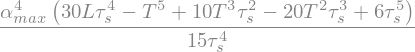


As polynomial in T:
  T^5: -alpha_max**4/(15*tau_s**4)
  T^3: 2*alpha_max**4/(3*tau_s**2)
  T^2: -4*alpha_max**4/(3*tau_s)
  T^0: 2*alpha_max**4*(5*L + tau_s)/5

R_Gamma(0) = 2*alpha_max**4*(5*L + tau_s)/5
Expected: amax^4 * (2*L + 2*ts/5) = amax^4 * (ell + 2*tau_s/5)
Expected R(0) = 2*alpha_max**4*(5*L + tau_s)/5
Match: True


In [24]:
# Total R_Gamma for T in [0, ts]:
R_interval_1 = simplify(I1 + I2 + I3 + I4 + I5)
print("R_Gamma(T) for T ∈ [0, τ_s]:")
display(R_interval_1)
print()

# Collect by powers of T
R_poly = sp.Poly(sp.expand(R_interval_1), T)
print("As polynomial in T:")
for power, coeff in sorted(R_poly.as_dict().items(), reverse=True):
    print(f"  T^{power[0]}: {simplify(coeff)}")

# Verify at T=0: should give R_Gamma(0) = int Gamma^2 ds
R_at_0 = R_interval_1.subs(T, 0)
print(f"\nR_Gamma(0) = {simplify(R_at_0)}")
print(f"Expected: amax^4 * (2*L + 2*ts/5) = amax^4 * (ell + 2*tau_s/5)")

# Check: int_{-S}^{S} Gamma^2(s) ds = amax^4 * [2L + 2*int_L^S ((S-s)/ts)^4 ds]
# = amax^4 * [2L + 2*ts/5]
expected_R0 = simplify(a2**2 * (2*L + 2*ts/5))
print(f"Expected R(0) = {expected_R0}")
print(f"Match: {simplify(R_at_0 - expected_R0) == 0}")

For T ∈ [τ_s, 2L] (assuming L > τ_s):
Sub-intervals: [-S,-L], [-L,L-T], [L-T,S-T]

J1 (ramp_neg × plateau):


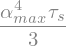


J2 (plateau × plateau):



J3 (plateau × ramp_pos):


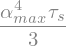


R_Gamma(T) for T ∈ [τ_s, 2L]:


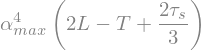

In [25]:
# Now compute R_Gamma for the remaining tau intervals.
# For T in [ts, 2L] (assuming L > ts):
# Breakpoints shift. Key change: the ramp-ramp overlap regions shrink to zero
# when T > ts, and eventually the plateau-plateau overlap vanishes when T > 2L.

# For T in [ts, 2L]:
# Sorted breakpoints: -S, -L-T, -L, -T(?), L-T, L, S-T
# But -L-T < -S when T > ts, so -L-T is outside integration range.
# Integration range: [-S, S-T]
# Breakpoints within: -S, -L, L-T, L, S-T
# (assuming ts < T < 2L, so 0 < L-T < L and 0 < S-T < S)
#
# Sub-intervals:
#   [-S, -L]:        ramp_neg(s), plateau(s+T)   [since s+T in [-S+T, -L+T], and -L+T > -L+ts > 0 > -L, so s+T in plateau if T > ts]
#   [-L, L-T]:       plateau(s), plateau(s+T)
#   [L-T, L]:        plateau(s), ramp_pos(s+T)
#   [L, S-T]:        ramp_pos(s), ramp_pos(s+T)

# Wait, need to check Gamma(s+T) at s = -S: s+T = -S+T = -L+T-ts+T... 
# Let me be more careful. At s = -S = -(L+ts): s+T = T-L-ts. 
# For T in [ts, 2L]: T-L-ts ranges from ts-L-ts = -L to 2L-L-ts = L-ts.
# So s+T ranges from -(L) to ... at s=-S. That means s+T = T-S.
# For T >= ts: T-S = T-L-ts >= ts-L-ts = -L, so s+T >= -L => Gamma(s+T) is in plateau.
# At s = -L: s+T = T-L. For T >= ts: T-L >= ts-L. For T < L: T-L < 0 < L => plateau.
# At s = L-T: s+T = L. Transition to ramp_pos.
# At s = L: s+T = L+T. For T < ts+L: s+T < 2L+ts = S+L... hmm, s+T = L+T <= L+2L = 3L.
# Need s+T <= S = L+ts. So s+T in ramp_pos when L < s+T <= S, i.e., s in [L-T, S-T].

# Check: at s = L, s+T = L+T. Is L+T <= S? S = L+ts, so L+T <= L+ts iff T <= ts.
# But we're in interval T > ts! So at s = L, Gamma(s+T) = 0 if T > ts.
# 
# Hmm, let me reconsider. For T > ts and s = L: s+T = L+T > L+ts = S => Gamma(s+T) = 0.
# So there's no ramp_pos x ramp_pos contribution for T > ts!

# For T in [ts, 2L]:
# Gamma(s+T) is nonzero when |s+T| <= S, i.e., s in [-S-T, S-T].
# But Gamma(s) is nonzero when |s| <= S, i.e., s in [-S, S].
# Overlap: s in [-S, S-T] (since S-T < S and -S < -S-T+2S = S-T... anyway -S > -S-T).
# 
# Now S-T = L+ts-T. For T in [ts, L+ts]: S-T ranges from L down to 0.
# For T in [ts, 2L]: S-T ranges from L down to ts-L (which could be negative if 2L > L+ts, i.e., L > ts).
# 
# Breakpoints of Gamma(s) within [-S, S-T]: -S, -L, L, and maybe S-T (if S-T > L, i.e., T < ts, no).
# So for T > ts: breakpoints of Gamma(s) in [-S, S-T] are: -S, -L, and L (if S-T > L, else just -S, -L, S-T)
# S-T > L iff T < ts. So for T >= ts: S-T <= L. Breakpoints: -S, -L, S-T.
#
# Breakpoints of Gamma(s+T): s+T = -L at s = -L-T (outside [-S, S-T] if L+T > S, i.e., T > ts)
# s+T = L at s = L-T.   For T <= 2L: L-T >= -L, which is in [-S, S-T].
# s+T = S at s = S-T.   This is the upper limit.
# s+T = -S at s = -S-T. Outside range.
#
# So for T in [ts, 2L], breakpoints within [-S, S-T]:
#   -S, -L, L-T, S-T
# With the constraint that -L < L-T (i.e., T < 2L, yes) and L-T < S-T (i.e., L < S, yes).

# Sub-intervals for T in [ts, 2L]:
#   [-S, -L]:     Gamma(s) = ramp_neg = a^2*((s+S)/ts)^2
#                 Gamma(s+T): s+T in [T-S, T-L]. T-S = T-L-ts ∈ [-L, L-ts] ∈ [-L, L] => plateau
#   [-L, L-T]:    Gamma(s) = plateau = a^2
#                 Gamma(s+T): s+T in [T-L, L]. T-L ∈ [ts-L, L] => could be in [-L,L] = plateau
#                 Actually T-L >= ts-L. If ts < L then T-L > 0 for T > L, but T-L could be in [-L,L].
#                 Since |s+T| = |s+T| and s+T = T+s. For s in [-L, L-T]: s+T in [T-L, L].
#                 T-L >= ts - L > -L (since ts > 0). So s+T >= T-L > -L => plateau.
#   [L-T, S-T]:   Gamma(s) = plateau (if L-T < L, which is true for T > 0) 
#                 Wait: for s in [L-T, S-T], is s < L? S-T = L+ts-T. For T >= ts: S-T <= L.
#                 So s in [L-T, S-T] and S-T <= L. So s <= L => plateau.
#                 Gamma(s+T): s+T in [L, S] => ramp_pos = a^2*((S-s-T)/ts)^2

print("For T ∈ [τ_s, 2L] (assuming L > τ_s):")
print("Sub-intervals: [-S,-L], [-L,L-T], [L-T,S-T]")
print()

# Sub-interval 1: s in [-S, -L], ramp_neg × plateau
J1 = integrate(ramp_neg_s * plateau_st, (s, -S, -L))
J1 = simplify(J1)
print("J1 (ramp_neg × plateau):")
display(J1)

# Sub-interval 2: s in [-L, L-T], plateau × plateau
J2 = integrate(plateau_s * plateau_st, (s, -L, L-T))
J2 = simplify(J2)
print("\nJ2 (plateau × plateau):")
display(J2)

# Sub-interval 3: s in [L-T, S-T], plateau × ramp_pos
J3 = integrate(plateau_s * ramp_pos_st, (s, L-T, S-T))
J3 = simplify(J3)
print("\nJ3 (plateau × ramp_pos):")
display(J3)

R_interval_2 = simplify(J1 + J2 + J3)
print("\nR_Gamma(T) for T ∈ [τ_s, 2L]:")
display(R_interval_2)

For T ∈ [2L, 2L+τ_s] (assuming L > τ_s):

K1 (ramp_neg × plateau):


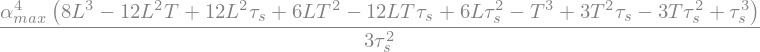


K2 (ramp_neg × ramp_pos):


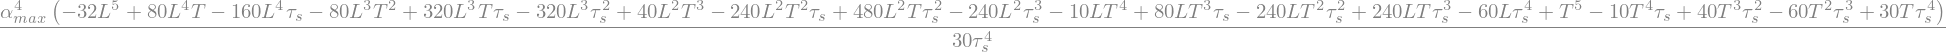


K3 (plateau × ramp_pos):


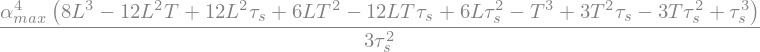


R_Gamma(T) for T ∈ [2L, 2L+τ_s]:


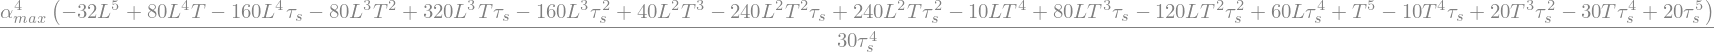

In [26]:
# For T in [2L, 2L+ts]:
# The plateau-plateau overlap vanishes. S-T = L+ts-T ∈ [ts-L, ts].
# Since ts < L, we have S-T in [ts-L, ts], and ts-L < 0 is possible... 
# Actually for T=2L: S-T = ts. For T=2L+ts: S-T = 0.
# So integration range: [-S, S-T] = [-(L+ts), L+ts-T]
#
# Breakpoints of Gamma(s): -S, -L (and L, S are outside since S-T < ts < L)
# Breakpoints of Gamma(s+T): s+T = L at s = L-T ∈ [-L, -L+ts]. 
#   For T in [2L, 2L+ts]: L-T ∈ [-L-ts, -L] = [-S, -L]. So L-T is in range.
#   s+T = S at s = S-T (upper limit).
#
# Sorted: -S, L-T, -L, S-T  -- but is L-T < -L? L-T < -L iff T > 2L, yes.
# So sorted: -S, L-T, -L, S-T.
#
# Sub-intervals:
#   [-S, L-T]:    Gamma(s) = ramp_neg, Gamma(s+T): s+T in [T-S, L] and T-S >= L (since T >= 2L, ts > 0)
#                 Actually T-S = T-L-ts. For T=2L: T-S = L-ts. For T=2L+ts: T-S=L.
#                 So s+T in [T-S, L], T-S ∈ [L-ts, L] => all in plateau range [-L, L]? 
#                 L-ts > -L since L > ts. Yes, plateau.
#   [L-T, -L]:   Gamma(s) = ramp_neg, Gamma(s+T): s+T in [L, T-L]. T-L ∈ [L, L+ts] = [L, S] => ramp_pos
#   [-L, S-T]:   Gamma(s) = plateau, Gamma(s+T): s+T in [T-L, S]. T-L ∈ [L, L+ts] => ramp_pos

print("For T ∈ [2L, 2L+τ_s] (assuming L > τ_s):")
print()

# Sub-interval 1: s in [-S, L-T], ramp_neg × plateau
K1 = integrate(ramp_neg_s * plateau_st, (s, -S, L-T))
K1 = simplify(K1)
print("K1 (ramp_neg × plateau):")
display(K1)

# Sub-interval 2: s in [L-T, -L], ramp_neg × ramp_pos
K2 = integrate(ramp_neg_s * ramp_pos_st, (s, L-T, -L))
K2 = simplify(K2)
print("\nK2 (ramp_neg × ramp_pos):")
display(K2)

# Sub-interval 3: s in [-L, S-T], plateau × ramp_pos
K3 = integrate(plateau_s * ramp_pos_st, (s, -L, S-T))
K3 = simplify(K3)
print("\nK3 (plateau × ramp_pos):")
display(K3)

R_interval_3 = simplify(K1 + K2 + K3)
print("\nR_Gamma(T) for T ∈ [2L, 2L+τ_s]:")
display(R_interval_3)

For T ∈ [2L+τ_s, 2(L+τ_s)]:



M1 (ramp_neg × ramp_pos, full overlap):


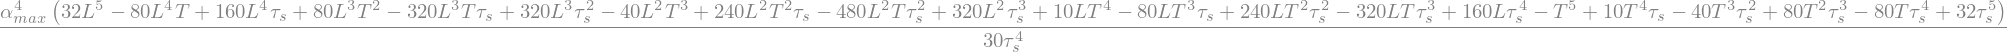


R_Gamma(T) for T ∈ [2L+τ_s, 2S]:


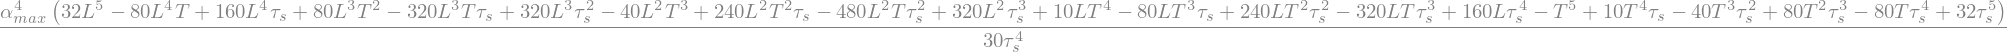

In [27]:
# For T in [2L+ts, 2L+2ts] = [2L+ts, 2S]:
# Integration range: [-S, S-T]. S-T = L+ts-T ∈ [-L, 0] for T in [2L+ts, 2S].
# Both Gamma(s) and Gamma(s+T) are in ramp regions for entire overlap.
#
# Breakpoints: -S, L-T, S-T. 
# L-T for T in [2L+ts, 2S]: L-T ∈ [-L-2ts, -L-ts] = below -S. So L-T < -S, outside.
# Only interval: [-S, S-T], ramp_neg(s) × ramp_pos(s+T)

print("For T ∈ [2L+τ_s, 2(L+τ_s)]:")
print()

M1 = integrate(ramp_neg_s * ramp_pos_st, (s, -S, S-T))
M1 = simplify(M1)
print("M1 (ramp_neg × ramp_pos, full overlap):")
display(M1)

R_interval_4 = M1
print("\nR_Gamma(T) for T ∈ [2L+τ_s, 2S]:")
display(R_interval_4)

In [28]:
# Verify all four pieces numerically
print("Numerical verification (L=2, ts=1, amax=1):")
print("=" * 60)

test_points = [
    (0.5, "[0, τ_s]", R_interval_1),
    (2.0, "[τ_s, 2L]", R_interval_2),
    (4.5, "[2L, 2L+τ_s]", R_interval_3),
    (5.5, "[2L+τ_s, 2S]", R_interval_4),
]

for T_val, label, R_expr in test_points:
    R_sym = float(R_expr.subs([(T, T_val), (L, 2), (ts, 1), (amax, 1)]))
    R_num = R_Gamma_numerical(T_val, L_n=2.0, ts_n=1.0, amax_n=1.0)
    match = abs(R_sym - R_num) < 1e-4
    print(f"  T={T_val} ({label}): symbolic={R_sym:.6f}, numerical={R_num:.6f}, match={match}")

Numerical verification (L=2, ts=1, amax=1):
  T=0.5 ([0, τ_s]): symbolic=4.147917, numerical=4.147917, match=True
  T=2.0 ([τ_s, 2L]): symbolic=2.666667, numerical=2.666667, match=True
  T=4.5 ([2L, 2L+τ_s]): symbolic=0.230208, numerical=0.230208, match=True
  T=5.5 ([2L+τ_s, 2S]): symbolic=0.001042, numerical=0.001042, match=True


In [29]:
# Final summary: display the piecewise R_Gamma(T) in terms of ell and tau_s
# Recall: L = ell/2, S = L + ts = ell/2 + tau_s

ell_sym = sp.Symbol('ell', positive=True)
tau_s_sym = sp.Symbol('tau_s', positive=True)

# Substitute L = ell/2
subs_dict = {L: ell_sym/2, ts: tau_s_sym}

print("CLOSED-FORM R_Γ(τ) for the squared trapezoidal envelope")
print("(assuming ℓ/2 > τ_s, i.e., plateau longer than ramp)")
print("=" * 60)
print()

intervals = [
    (f"0 ≤ τ ≤ τ_s", R_interval_1),
    (f"τ_s ≤ τ ≤ ℓ", R_interval_2),
    (f"ℓ ≤ τ ≤ ℓ + τ_s", R_interval_3),
    (f"ℓ + τ_s ≤ τ ≤ ℓ + 2τ_s", R_interval_4),
]

R_pieces = []
for label, R_expr in intervals:
    R_sub = simplify(R_expr.subs(subs_dict))
    R_pieces.append(R_sub)
    print(f"  {label}:")
    display(Math(rf"R_\Gamma(\tau) = {latex(R_sub)}"))
    print()

print("  τ > ℓ + 2τ_s:  R_Γ(τ) = 0")

CLOSED-FORM R_Γ(τ) for the squared trapezoidal envelope
(assuming ℓ/2 > τ_s, i.e., plateau longer than ramp)

  0 ≤ τ ≤ τ_s:


<IPython.core.display.Math object>


  τ_s ≤ τ ≤ ℓ:


<IPython.core.display.Math object>


  ℓ ≤ τ ≤ ℓ + τ_s:


<IPython.core.display.Math object>

  ℓ + τ_s ≤ τ ≤ ℓ + 2τ_s:

<IPython.core.display.Math object>


  τ > ℓ + 2τ_s:  R_Γ(τ) = 0
